# NHS A&E Performance & Waiting Times Analysis
## October 2025 – January 2026

**Objective:** Analyse publicly available NHS England A&E Attendances and Emergency Admissions data to identify trends in waiting times, seasonal demand patterns, and trust-level performance variation.

**Data Source:** [NHS England Monthly A&E Attendances and Emergency Admissions Statistics](https://www.england.nhs.uk/statistics/statistical-work-areas/ae-waiting-times-and-activity/)

**Scope:**
- 4 months of data: October 2025, November 2025, December 2025, January 2026
- All NHS England A&E providers (Type 1, Type 2, and Other departments)
- Key metrics: attendances, 4-hour target compliance, DTA waiting times, emergency admissions

---

## 1. Setup & Configuration

Import required libraries and define project-wide constants including the NHS colour palette and plotting defaults.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import numpy as np
from scipy import stats
import os
import warnings

warnings.filterwarnings("ignore")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [4]:
# ── Directory Configuration ──────────────────────────────────────────────────

DATA_DIR = os.path.join(os.getcwd(), "data")
OUTPUT_DIR = os.path.join(os.getcwd(), "output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Month ordering ───────────────────────────────────────────────────────────

MONTH_ORDER = ["October-2025", "November-2025", "December-2025", "January-2026"]
MONTH_LABELS = ["Oct 2025", "Nov 2025", "Dec 2025", "Jan 2026"]

FILES = {
    "October-2025": "October-2025.csv",
    "November-2025": "November-2025.csv",
    "December-2025": "December-2025.csv",
    "January-2026": "January-2026.csv",
}

print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Months covered: {', '.join(MONTH_LABELS)}")

Data directory: C:\Users\Admin\Desktop\claude code\nhs-ae-analysis\data
Output directory: C:\Users\Admin\Desktop\claude code\nhs-ae-analysis\output
Months covered: Oct 2025, Nov 2025, Dec 2025, Jan 2026


In [7]:
# ── NHS-Inspired Colour Palette ──────────────────────────────────────────────

NHS_BLUE = "#005EB8"
NHS_DARK_BLUE = "#003087"
NHS_LIGHT_BLUE = "#41B6E6"
NHS_GREEN = "#009639"
NHS_RED = "#DA291C"
NHS_AMBER = "#ED8B00"
NHS_WARM_YELLOW = "#FAE100"
NHS_GREY = "#768692"
NHS_PALE_GREY = "#E8EDEE"
NHS_DARK_GREY = "#425563"

PALETTE = [NHS_BLUE, NHS_RED, NHS_GREEN, NHS_AMBER, NHS_LIGHT_BLUE, NHS_DARK_BLUE, "#7C2855", "#330072"]

SOURCE_TEXT = "Source: NHS England A&E Attendances and Emergency Admissions, Monthly Statistics (Oct 2025 – Jan 2026)"

print("NHS colour palette configured.")

NHS colour palette configured.


In [9]:
# ── Matplotlib Style Configuration ────────────────────────────────────────────

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.labelcolor": NHS_DARK_GREY,
    "axes.edgecolor": NHS_GREY,
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": NHS_PALE_GREY,
    "grid.linewidth": 0.6,
    "grid.alpha": 0.8,
    "xtick.color": NHS_DARK_GREY,
    "ytick.color": NHS_DARK_GREY,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.framealpha": 0.9,
    "legend.edgecolor": NHS_PALE_GREY,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

print("Professional plot style configured.")

Professional plot style configured.


In [11]:
# ── Helper Functions ──────────────────────────────────────────────────────────

def add_source_footnote(fig, text=SOURCE_TEXT):
    """Add a data source footnote at the bottom of every figure."""
    fig.text(0.5, -0.02, text, ha="center", va="top", fontsize=7, color=NHS_GREY, style="italic")


def add_figure_title(ax, fig_num, title, subtitle=None):
    """Add a numbered figure title with optional subtitle."""
    ax.set_title(f"Figure {fig_num}: {title}", fontsize=13, fontweight="bold",
                 color=NHS_DARK_BLUE, pad=15, loc="left")
    if subtitle:
        ax.text(0.0, 1.02, subtitle, transform=ax.transAxes, fontsize=9,
                color=NHS_GREY, style="italic", va="bottom")

print("Helper functions defined.")

Helper functions defined.


---

## 2. Data Loading & Cleaning

Load the four monthly CSV files, standardise column names, handle missing values, remove aggregate rows, and derive key performance metrics.

**Key cleaning steps:**
- Strip whitespace from column headers and string fields
- Remove national "TOTAL" rows to avoid double-counting
- Coerce numeric columns (handling non-numeric entries as NaN → 0)
- Derive calculated fields: total attendances, 4-hour compliance rate, DTA waiting categories

In [14]:
frames = []
for month, filename in FILES.items():
    path = os.path.join(DATA_DIR, filename)
    df = pd.read_csv(path)

    # Strip whitespace from column names
    df.columns = df.columns.str.strip()

    # Strip whitespace from string columns
    for col in ["Period", "Org Code", "Parent Org", "Org name"]:
        df[col] = df[col].astype(str).str.strip()

    # Drop the TOTAL / Total row
    df = df[~df["Org Code"].str.upper().isin(["TOTAL"])]

    # Convert numeric columns — coerce errors to NaN, then fill with 0
    numeric_cols = df.columns[4:]
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce").fillna(0).astype(int)

    df["Month"] = month
    frames.append(df)
    print(f"  Loaded {filename}: {len(df)} rows")

combined = pd.concat(frames, ignore_index=True)
print(f"\nCombined dataset: {len(combined)} rows across {combined['Month'].nunique()} months")

  Loaded October-2025.csv: 196 rows
  Loaded November-2025.csv: 197 rows
  Loaded December-2025.csv: 197 rows
  Loaded January-2026.csv: 197 rows

Combined dataset: 787 rows across 4 months


### 2.1 Feature Engineering

Derive additional metrics from the raw data for analysis:

In [17]:
# Standardise region names
combined["Region"] = combined["Parent Org"].str.replace("NHS ENGLAND ", "", regex=False).str.strip()

# Derive key metrics
combined["Total Attendances"] = (
    combined["A&E attendances Type 1"]
    + combined["A&E attendances Type 2"]
    + combined["A&E attendances Other A&E Department"]
)
combined["Total Over 4hrs"] = (
    combined["Attendances over 4hrs Type 1"]
    + combined["Attendances over 4hrs Type 2"]
    + combined["Attendances over 4hrs Other Department"]
)
combined["Total Emergency Admissions"] = (
    combined["Emergency admissions via A&E - Type 1"]
    + combined["Emergency admissions via A&E - Type 2"]
    + combined["Emergency admissions via A&E - Other A&E department"]
    + combined["Other emergency admissions"]
)
combined["Emergency Type 1"] = combined["Emergency admissions via A&E - Type 1"]
combined["Emergency Type 2"] = combined["Emergency admissions via A&E - Type 2"]
combined["Emergency Other"] = (
    combined["Emergency admissions via A&E - Other A&E department"]
    + combined["Other emergency admissions"]
)
combined["Waited 4-12hrs DTA"] = combined["Patients who have waited 4-12 hs from DTA to admission"]
combined["Waited 12+hrs DTA"] = combined["Patients who have waited 12+ hrs from DTA to admission"]

# 4-hour performance rate (% seen within 4 hours)
combined["Pct Within 4hrs"] = np.where(
    combined["Total Attendances"] > 0,
    ((combined["Total Attendances"] - combined["Total Over 4hrs"]) / combined["Total Attendances"]) * 100,
    np.nan,
)

print(f"Feature engineering complete.")
print(f"Unique trusts/providers: {combined['Org Code'].nunique()}")
print(f"Regions: {combined['Region'].nunique()}")
print(f"\nDerived columns added: Total Attendances, Total Over 4hrs, Total Emergency Admissions,")
print(f"  Emergency Type 1/2/Other, Waited 4-12hrs DTA, Waited 12+hrs DTA, Pct Within 4hrs")

Feature engineering complete.
Unique trusts/providers: 197
Regions: 7

Derived columns added: Total Attendances, Total Over 4hrs, Total Emergency Admissions,
  Emergency Type 1/2/Other, Waited 4-12hrs DTA, Waited 12+hrs DTA, Pct Within 4hrs


### 2.2 Data Preview

Quick inspection of the cleaned dataset structure and sample rows:

In [20]:
print(f"Dataset shape: {combined.shape}")
print(f"\nColumn types:\n{combined.dtypes.value_counts()}")
print(f"\nNull values in key columns:")
print(combined[["Total Attendances", "Total Over 4hrs", "Pct Within 4hrs", "Region"]].isnull().sum())
combined.head()

Dataset shape: (787, 33)

Column types:
int32      26
object      6
float64     1
Name: count, dtype: int64

Null values in key columns:
Total Attendances     0
Total Over 4hrs       0
Pct Within 4hrs      45
Region                0
dtype: int64


,Period,Org Code,Parent Org,Org name,A&E attendances Type 1,A&E attendances Type 2,A&E attendances Other A&E Department,A&E attendances Booked Appointments Type 1,A&E attendances Booked Appointments Type 2,A&E attendances Booked Appointments Other Department,...,Region,Total Attendances,Total Over 4hrs,Total Emergency Admissions,Emergency Type 1,Emergency Type 2,Emergency Other,Waited 4-12hrs DTA,Waited 12+hrs DTA,Pct Within 4hrs
0,MSitAE-OCTOBER-2025,RAN,NHS ENGLAND LONDON,ROYAL NATIONAL ORTHOPAEDIC HOSPITAL NHS TRUST,0,0,0,0,0,0,...,LONDON,0,0,24,0,0,24,0,0,NaN
1,MSitAE-OCTOBER-2025,RBQ,NHS ENGLAND NORTH WEST,LIVERPOOL HEART AND CHEST HOSPITAL NHS FOUNDAT...,0,0,0,0,0,0,...,NORTH WEST,0,0,172,0,0,172,0,0,NaN
2,MSitAE-OCTOBER-2025,RLQ,NHS ENGLAND MIDLANDS,WYE VALLEY NHS TRUST,6138,1143,127,107,0,0,...,MIDLANDS,7408,2478,1667,1495,0,172,417,272,66.549676
3,MSitAE-OCTOBER-2025,RYY,NHS ENGLAND SOUTH EAST,KENT COMMUNITY HEALTH NHS FOUNDATION TRUST,0,0,6140,0,0,0,...,SOUTH EAST,6140,13,0,0,0,0,0,0,99.788274
4,MSitAE-OCTOBER-2025,AAH,NHS ENGLAND SOUTH WEST,TETBURY HOSPITAL TRUST LTD,0,0,609,0,0,0,...,SOUTH WEST,609,0,0,0,0,0,0,0,100.000000


---

## 3. National Monthly Summary

Aggregate all trust-level data to produce national-level statistics per month. This provides the baseline for understanding macro trends before drilling into regional and trust-level variation.

In [23]:
monthly = (
    combined.groupby("Month")
    .agg(
        Total_Attendances=("Total Attendances", "sum"),
        Total_Over_4hrs=("Total Over 4hrs", "sum"),
        Emergency_Admissions=("Total Emergency Admissions", "sum"),
        Emergency_Type1=("Emergency Type 1", "sum"),
        Emergency_Type2=("Emergency Type 2", "sum"),
        Emergency_Other=("Emergency Other", "sum"),
        Waited_4_12hrs=("Waited 4-12hrs DTA", "sum"),
        Waited_12plus_hrs=("Waited 12+hrs DTA", "sum"),
    )
    .reindex(MONTH_ORDER)
)
monthly["Pct_Within_4hrs"] = (
    (monthly["Total_Attendances"] - monthly["Total_Over_4hrs"]) / monthly["Total_Attendances"] * 100
)
monthly.index = MONTH_LABELS

print("=" * 80)
print("NATIONAL MONTHLY SUMMARY")
print("=" * 80)
monthly[["Total_Attendances", "Total_Over_4hrs", "Emergency_Admissions",
         "Waited_4_12hrs", "Waited_12plus_hrs", "Pct_Within_4hrs"]]

NATIONAL MONTHLY SUMMARY


,Total_Attendances,Total_Over_4hrs,Emergency_Admissions,Waited_4_12hrs,Waited_12plus_hrs,Pct_Within_4hrs
Oct 2025,2314177,610640,554193,88420,54314,73.613081
Nov 2025,2261926,595846,531747,83151,50648,73.657582
Dec 2025,2240325,599421,542195,86988,50775,73.244016
Jan 2026,2235959,629487,546136,89624,71517,71.847113


---

## 4. Visualisations

### Figure 1: Total A&E Attendances with Month-on-Month Change

A dual-axis chart combining absolute attendance volumes (bars) with the month-on-month percentage change (line). This reveals both the scale of demand and its trajectory — critical for capacity planning.

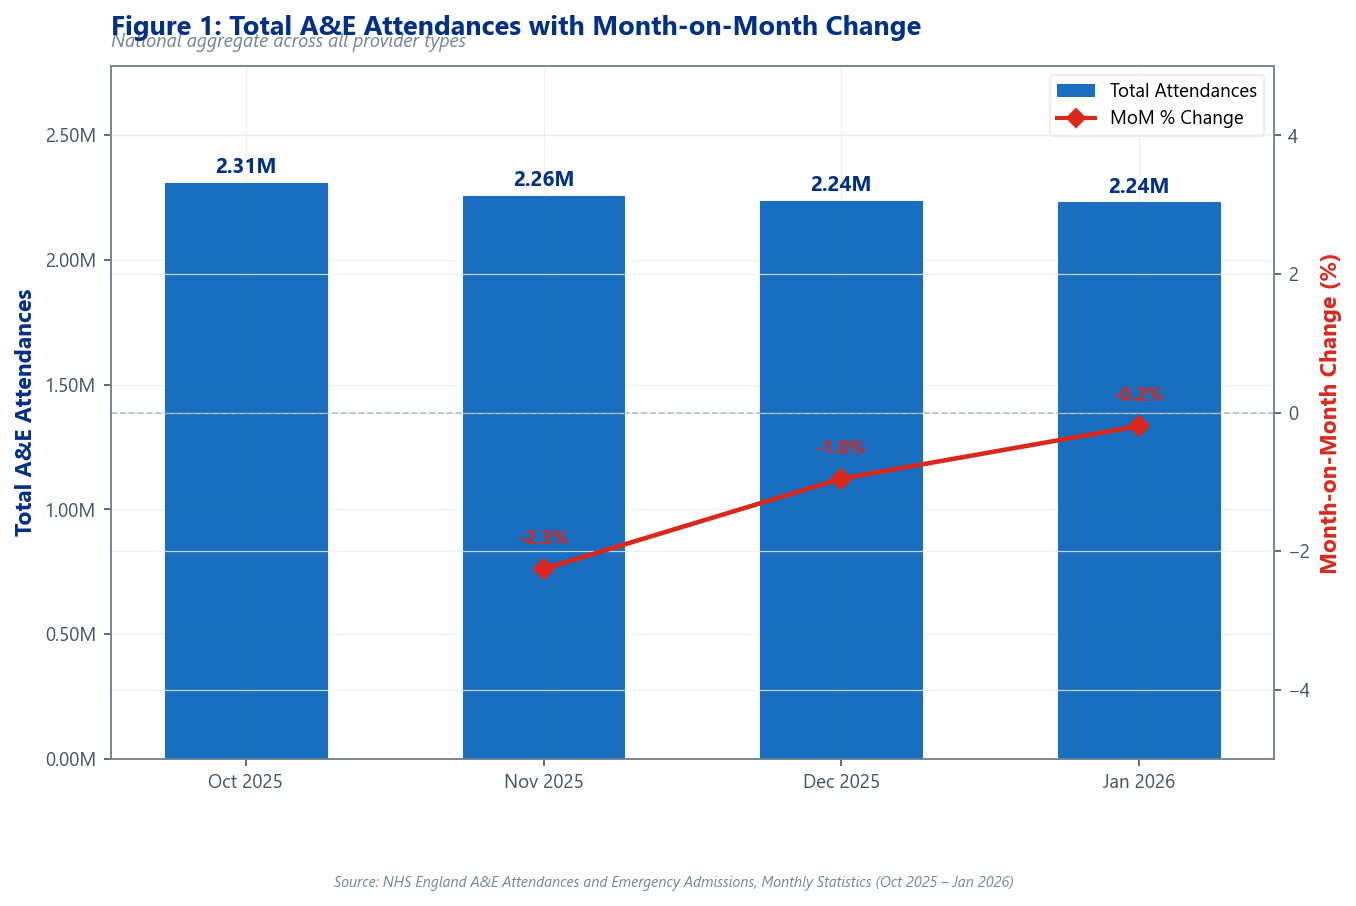

In [26]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bars
bars = ax1.bar(monthly.index, monthly["Total_Attendances"], color=NHS_BLUE,
               width=0.55, edgecolor="white", linewidth=0.5, alpha=0.9, zorder=3)
ax1.set_ylabel("Total A&E Attendances", color=NHS_DARK_BLUE, fontweight="bold")
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x / 1e6:.2f}M"))
ax1.set_ylim(0, monthly["Total_Attendances"].max() * 1.2)

for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height + 15000,
             f"{height / 1e6:.2f}M", ha="center", va="bottom", fontsize=10,
             fontweight="bold", color=NHS_DARK_BLUE)

# Month-on-month % change on secondary axis
ax2 = ax1.twinx()
pct_change = monthly["Total_Attendances"].pct_change() * 100
valid_idx = pct_change.dropna().index
ax2.plot(valid_idx, pct_change.dropna(), marker="D", color=NHS_RED,
         linewidth=2.2, markersize=7, zorder=5)
ax2.set_ylabel("Month-on-Month Change (%)", color=NHS_RED, fontweight="bold")
ax2.axhline(y=0, color=NHS_GREY, linewidth=0.8, linestyle="--", alpha=0.5)
ax2.set_ylim(-5, 5)

for idx, val in pct_change.dropna().items():
    ax2.annotate(f"{val:+.1f}%", (idx, val), textcoords="offset points",
                 xytext=(0, 12), ha="center", fontsize=9, fontweight="bold", color=NHS_RED)

# Legend
legend_elements = [
    mpatches.Patch(facecolor=NHS_BLUE, alpha=0.9, label="Total Attendances"),
    Line2D([0], [0], color=NHS_RED, marker="D", linewidth=2, markersize=6, label="MoM % Change"),
]
ax1.legend(handles=legend_elements, loc="upper right", framealpha=0.9)

add_figure_title(ax1, 1, "Total A&E Attendances with Month-on-Month Change",
                 "National aggregate across all provider types")
add_source_footnote(fig)
fig.savefig(os.path.join(OUTPUT_DIR, "01_monthly_attendances.png"))
plt.show()

### Figure 2: 4-Hour A&E Performance vs National Target

The NHS Constitution sets a standard that 95% of patients attending A&E should be admitted, transferred, or discharged within 4 hours. This gap chart visualises the shortfall between actual performance and this target, highlighting the persistent and widening breach.

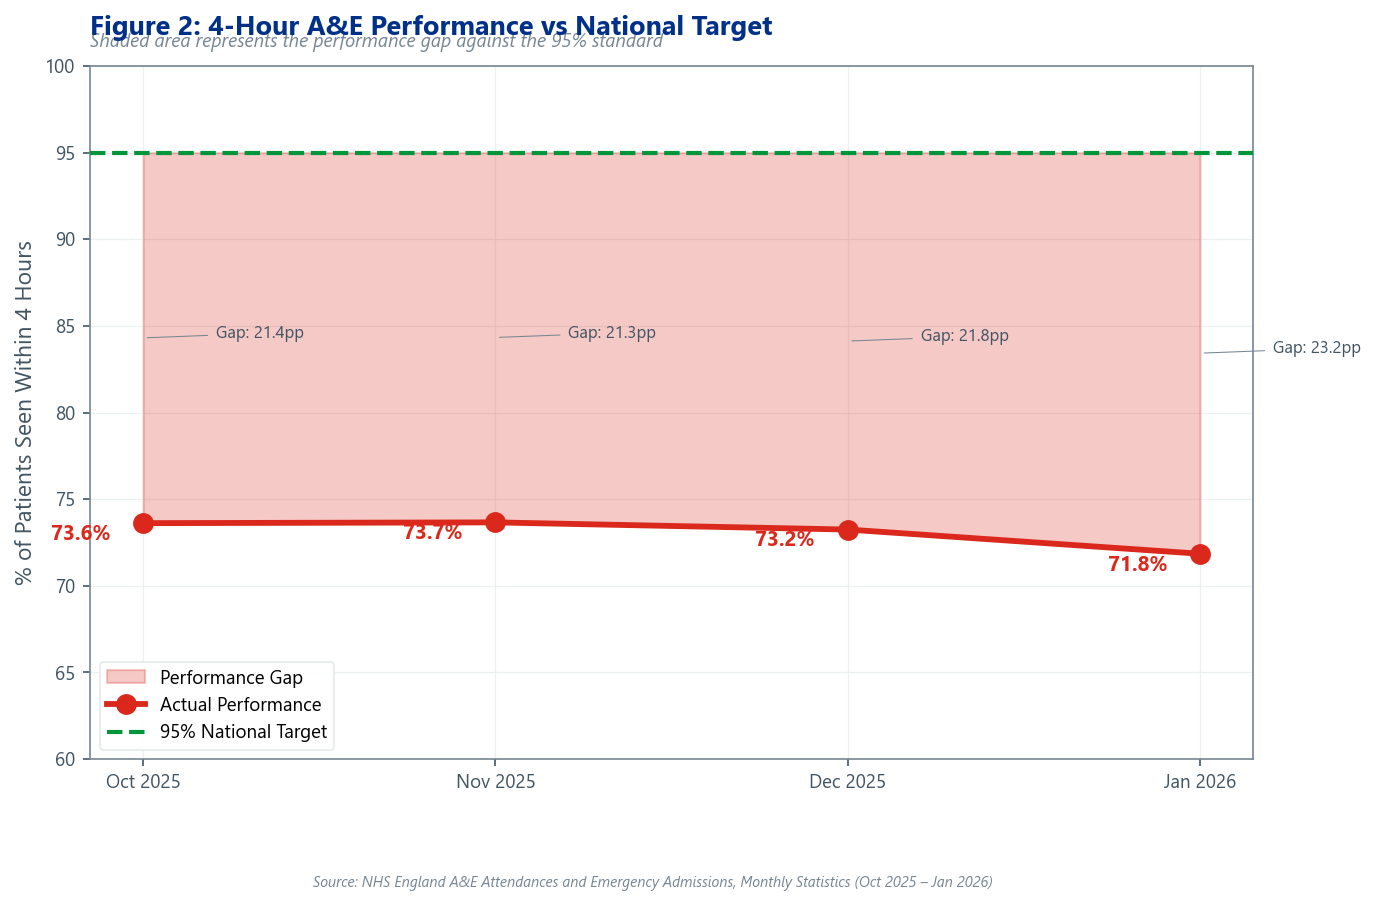

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

target = 95
actual = monthly["Pct_Within_4hrs"].values
x = np.arange(len(monthly.index))

# Shaded gap area
ax.fill_between(x, actual, target, alpha=0.25, color=NHS_RED, label="Performance Gap")
ax.plot(x, actual, marker="o", linewidth=2.8, color=NHS_RED, markersize=9, zorder=5,
        label="Actual Performance")
ax.axhline(y=target, color=NHS_GREEN, linewidth=2, linestyle="--", label="95% National Target", zorder=4)

# Annotate gap sizes
for i, val in enumerate(actual):
    gap = target - val
    ax.annotate(f"{val:.1f}%", (x[i], val), textcoords="offset points",
                xytext=(-30, -8), ha="center", fontsize=10, fontweight="bold", color=NHS_RED)
    mid = (val + target) / 2
    ax.annotate(f"Gap: {gap:.1f}pp", (x[i], mid), textcoords="offset points",
                xytext=(35, 0), ha="left", fontsize=8, color=NHS_DARK_GREY,
                arrowprops=dict(arrowstyle="-", color=NHS_GREY, lw=0.5))

ax.set_xticks(x)
ax.set_xticklabels(monthly.index)
ax.set_ylabel("% of Patients Seen Within 4 Hours")
ax.set_ylim(60, 100)
ax.legend(loc="lower left", framealpha=0.95)

add_figure_title(ax, 2, "4-Hour A&E Performance vs National Target",
                 "Shaded area represents the performance gap against the 95% standard")
add_source_footnote(fig)
fig.savefig(os.path.join(OUTPUT_DIR, "02_4hr_performance_gap.png"))
plt.show()

### Figure 3: Decision to Admit (DTA) Waiting Times Breakdown

Patients waiting excessively after a decision to admit is made represent a critical bottleneck — often linked to bed availability, staffing, and flow issues. This stacked bar chart decomposes waits into 4–12 hour and 12+ hour categories, with a secondary axis tracking the proportion of long waits (12+ hours).

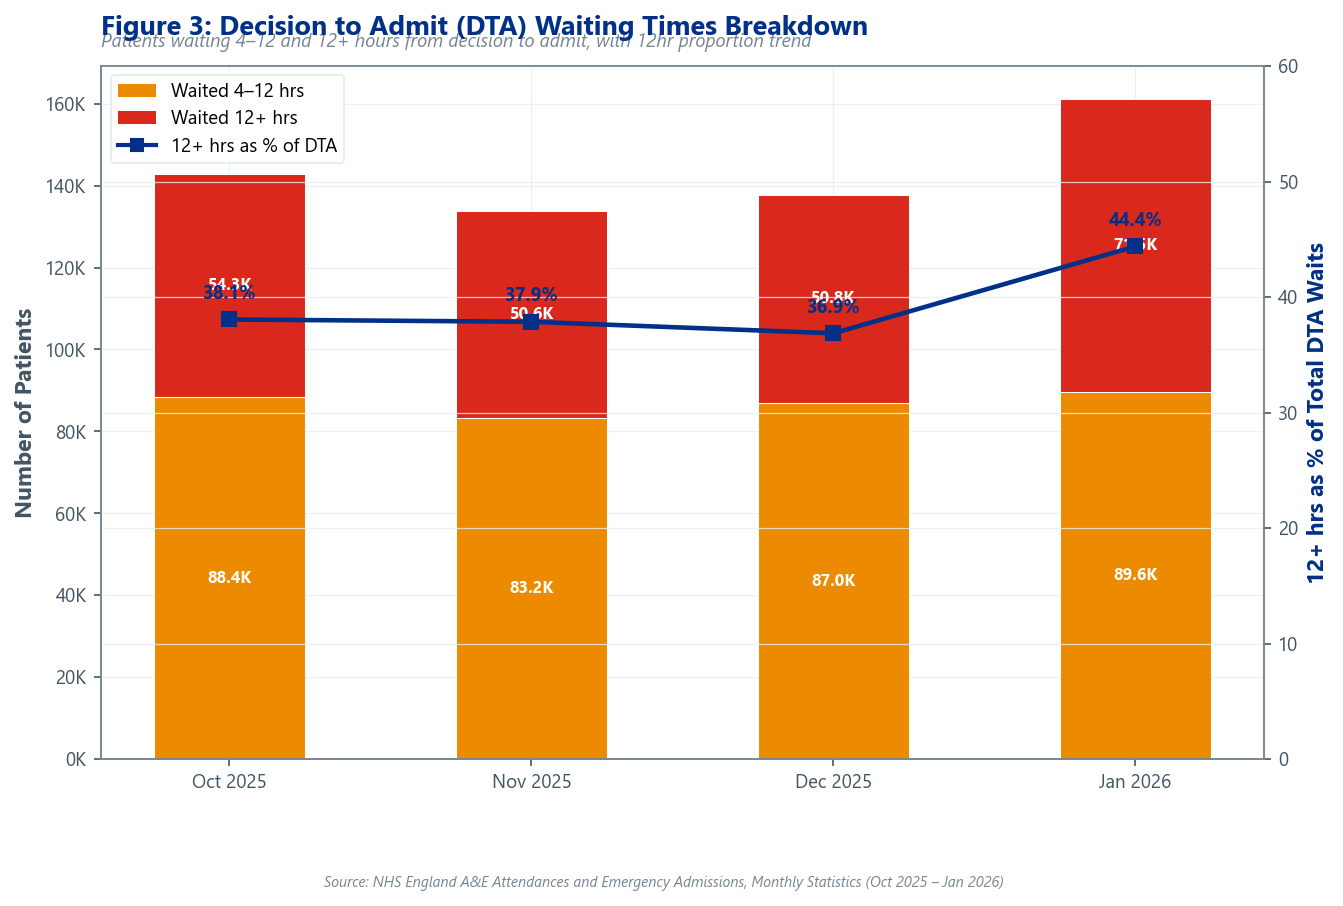

In [31]:
fig, ax1 = plt.subplots(figsize=(10, 6))

x = np.arange(len(monthly.index))
w = 0.5
waited_4_12 = monthly["Waited_4_12hrs"].values
waited_12plus = monthly["Waited_12plus_hrs"].values
total_dta = waited_4_12 + waited_12plus

# Stacked bars
bars1 = ax1.bar(x, waited_4_12, w, label="4–12 hours", color=NHS_AMBER, edgecolor="white", linewidth=0.5)
bars2 = ax1.bar(x, waited_12plus, w, bottom=waited_4_12, label="12+ hours",
                color=NHS_RED, edgecolor="white", linewidth=0.5)

# Labels on bars
for i in range(len(x)):
    ax1.text(x[i], waited_4_12[i] / 2, f"{waited_4_12[i] / 1e3:.1f}K",
             ha="center", va="center", fontsize=8, color="white", fontweight="bold")
    ax1.text(x[i], waited_4_12[i] + waited_12plus[i] / 2, f"{waited_12plus[i] / 1e3:.1f}K",
             ha="center", va="center", fontsize=8, color="white", fontweight="bold")

ax1.set_xticks(x)
ax1.set_xticklabels(monthly.index)
ax1.set_ylabel("Number of Patients", fontweight="bold")
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x / 1e3:.0f}K"))

# Proportion line on secondary axis
ax2 = ax1.twinx()
pct_12plus = (waited_12plus / total_dta) * 100
ax2.plot(x, pct_12plus, marker="s", color=NHS_DARK_BLUE, linewidth=2.2, markersize=7, zorder=5)
ax2.set_ylabel("12+ hrs as % of Total DTA Waits", color=NHS_DARK_BLUE, fontweight="bold")
ax2.set_ylim(0, 60)
for i, val in enumerate(pct_12plus):
    ax2.annotate(f"{val:.1f}%", (x[i], val), textcoords="offset points",
                 xytext=(0, 10), ha="center", fontsize=9, fontweight="bold", color=NHS_DARK_BLUE)

# Combined legend
legend_elements = [
    mpatches.Patch(facecolor=NHS_AMBER, label="Waited 4–12 hrs"),
    mpatches.Patch(facecolor=NHS_RED, label="Waited 12+ hrs"),
    Line2D([0], [0], color=NHS_DARK_BLUE, marker="s", linewidth=2, markersize=6,
           label="12+ hrs as % of DTA"),
]
ax1.legend(handles=legend_elements, loc="upper left", framealpha=0.95)

add_figure_title(ax1, 3, "Decision to Admit (DTA) Waiting Times Breakdown",
                 "Patients waiting 4–12 and 12+ hours from decision to admit, with 12hr proportion trend")
add_source_footnote(fig)
fig.savefig(os.path.join(OUTPUT_DIR, "03_dta_waiting_times.png"))
plt.show()

### Figure 4: Regional 4-Hour Performance (Lollipop Chart)

This lollipop chart ranks NHS England regions by their 4-hour performance in the latest month. The colour coding (red/amber/green) provides an at-a-glance RAG status, while the national average reference line allows quick identification of above- and below-average regions.

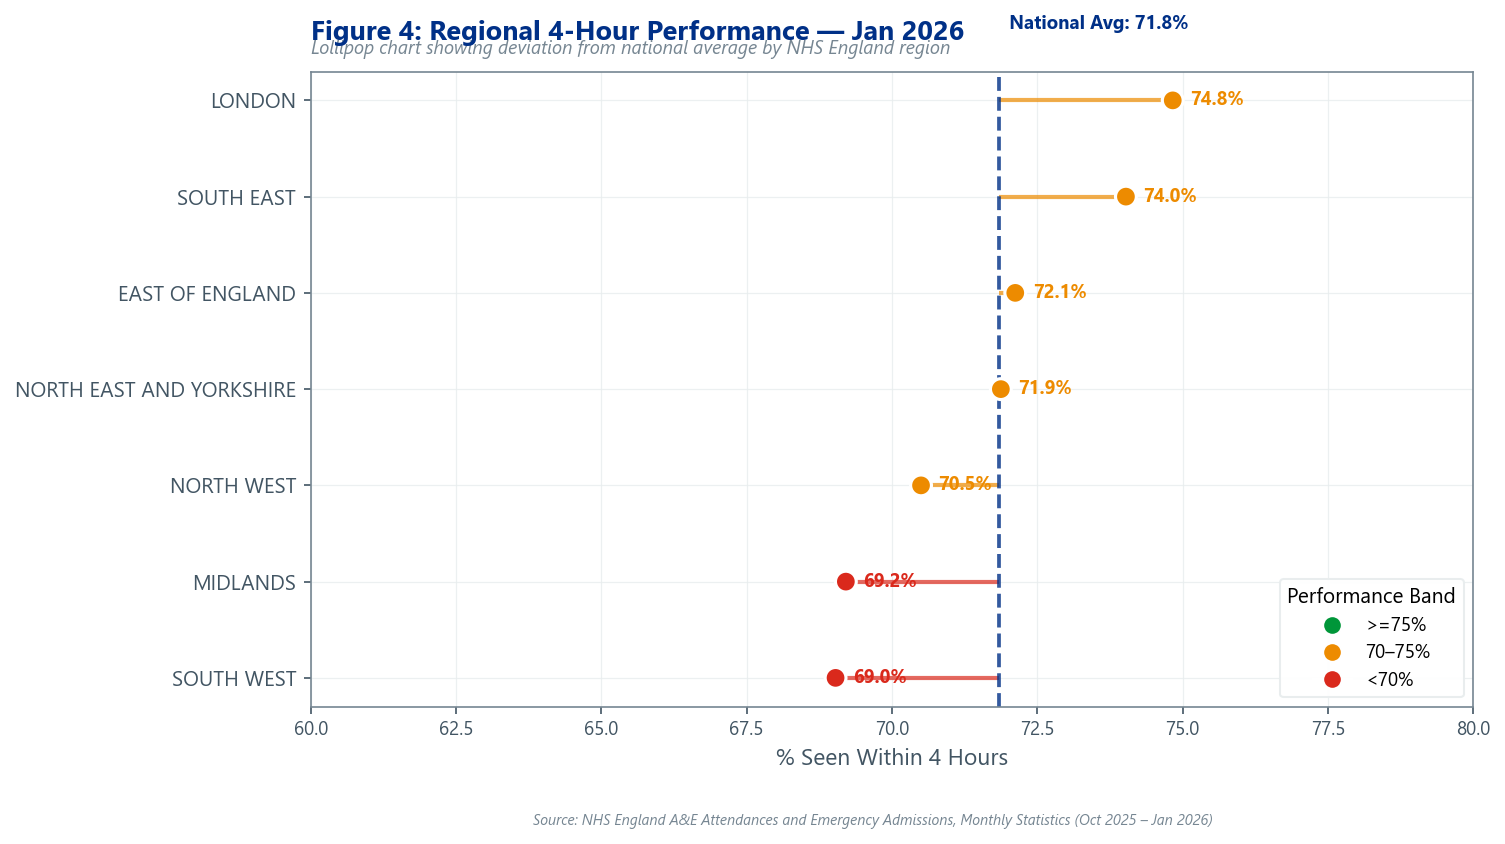

In [34]:
latest = combined[combined["Month"] == MONTH_ORDER[-1]]
regional = (
    latest.groupby("Region")
    .agg(Attendances=("Total Attendances", "sum"), Over4hrs=("Total Over 4hrs", "sum"))
)
regional = regional[regional["Attendances"] > 0]
regional["Pct_Within_4hrs"] = (
    (regional["Attendances"] - regional["Over4hrs"]) / regional["Attendances"] * 100
)
regional = regional.sort_values("Pct_Within_4hrs")
nat_avg = (regional["Attendances"].sum() - regional["Over4hrs"].sum()) / regional["Attendances"].sum() * 100

fig, ax = plt.subplots(figsize=(10, 5.5))

y = np.arange(len(regional))
values = regional["Pct_Within_4hrs"].values

# Colour code: red < 70, amber 70-75, green >= 75
colors = [NHS_RED if v < 70 else NHS_AMBER if v < 75 else NHS_GREEN for v in values]

# Stems
for i, (val, col) in enumerate(zip(values, colors)):
    ax.hlines(y=i, xmin=nat_avg, xmax=val, color=col, linewidth=2, alpha=0.7)

# Dots
ax.scatter(values, y, c=colors, s=100, zorder=5, edgecolors="white", linewidth=1.5)

# National average line
ax.axvline(x=nat_avg, color=NHS_DARK_BLUE, linewidth=1.8, linestyle="--", alpha=0.8)
ax.text(nat_avg, len(y) - 0.3, f"  National Avg: {nat_avg:.1f}%", fontsize=9,
        color=NHS_DARK_BLUE, fontweight="bold", va="bottom")

ax.set_yticks(y)
ax.set_yticklabels(regional.index, fontsize=10)
ax.set_xlabel("% Seen Within 4 Hours")
ax.set_xlim(60, 80)

for i, val in enumerate(values):
    ax.text(val + 0.3, i, f"{val:.1f}%", va="center", fontsize=9, fontweight="bold", color=colors[i])

# Legend
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=NHS_GREEN, markersize=9, label=">=75%"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=NHS_AMBER, markersize=9, label="70–75%"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=NHS_RED, markersize=9, label="<70%"),
]
ax.legend(handles=legend_elements, loc="lower right", title="Performance Band", framealpha=0.95)

add_figure_title(ax, 4, f"Regional 4-Hour Performance — {MONTH_LABELS[-1]}",
                 "Lollipop chart showing deviation from national average by NHS England region")
add_source_footnote(fig)
fig.savefig(os.path.join(OUTPUT_DIR, "04_regional_lollipop.png"))
plt.show()

### Figure 5: Trust-Level Performance — Diverging Bar Chart

Identifies the top 10 and bottom 10 performing trusts relative to the national average. This diverging bar chart centres on 0 (the national average) to clearly show which trusts are outperforming or underperforming, and by how much. Only trusts with >= 3,000 Type 1 attendances are included to ensure statistical reliability.

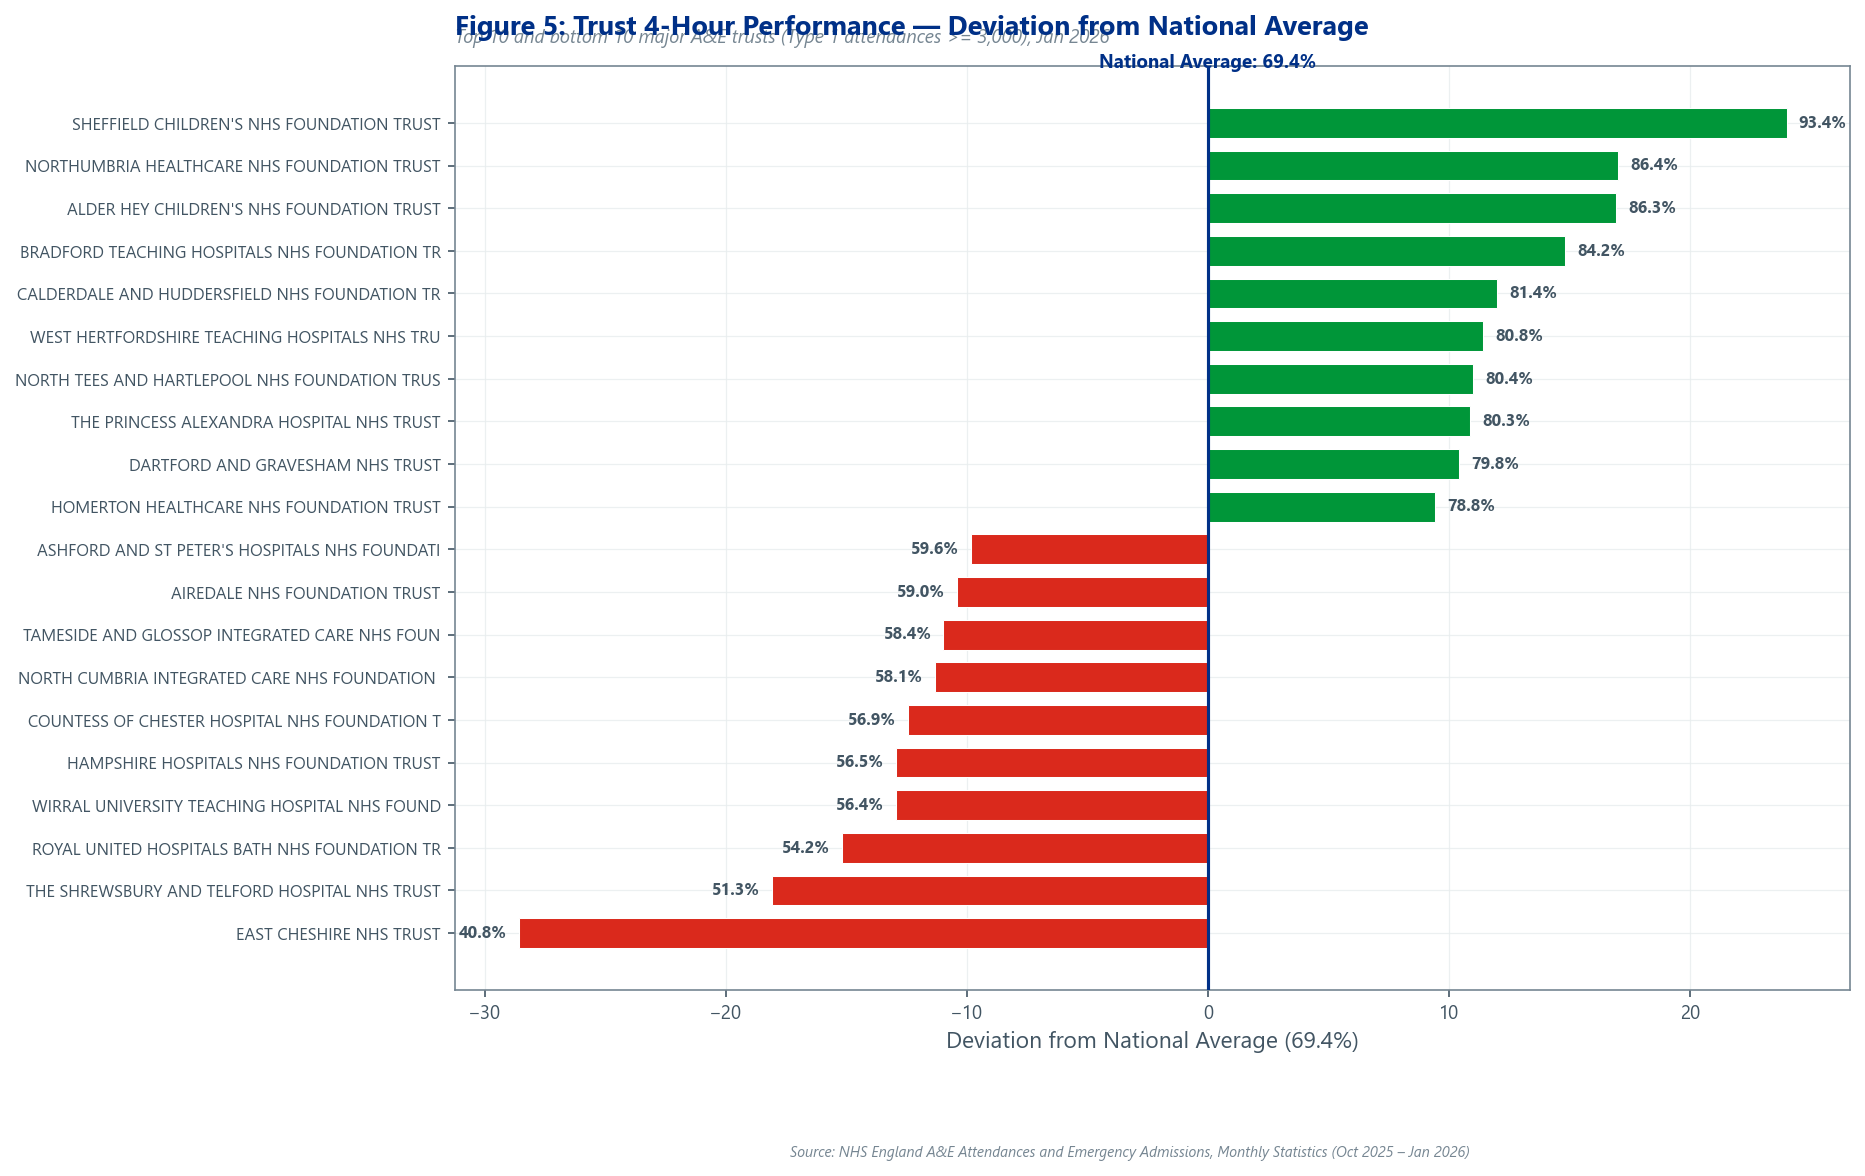

In [36]:
latest = combined[combined["Month"] == MONTH_ORDER[-1]]
trusts = latest[latest["A&E attendances Type 1"] >= 3000].copy()
trusts = trusts[trusts["Total Attendances"] > 0]
trusts["Pct_Within_4hrs"] = (
    (trusts["Total Attendances"] - trusts["Total Over 4hrs"]) / trusts["Total Attendances"] * 100
)

nat_avg = (trusts["Total Attendances"].sum() - trusts["Total Over 4hrs"].sum()) / trusts["Total Attendances"].sum() * 100
trusts["Deviation"] = trusts["Pct_Within_4hrs"] - nat_avg

# Top 10 and bottom 10
top10 = trusts.nlargest(10, "Deviation")
bot10 = trusts.nsmallest(10, "Deviation")
trust_combined = pd.concat([bot10, top10]).sort_values("Deviation")

fig, ax = plt.subplots(figsize=(12, 8))

y = np.arange(len(trust_combined))
colors = [NHS_GREEN if d >= 0 else NHS_RED for d in trust_combined["Deviation"]]

ax.barh(y, trust_combined["Deviation"], color=colors, edgecolor="white", linewidth=0.5, height=0.7)
ax.axvline(x=0, color=NHS_DARK_BLUE, linewidth=1.5, zorder=5)

# Trust name labels
labels = trust_combined["Org name"].str[:45].values
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=8)

# Value annotations
for i, (dev, pct) in enumerate(zip(trust_combined["Deviation"], trust_combined["Pct_Within_4hrs"])):
    offset = 0.5 if dev >= 0 else -0.5
    ha = "left" if dev >= 0 else "right"
    ax.text(dev + offset, i, f"{pct:.1f}%", va="center", ha=ha, fontsize=8,
            fontweight="bold", color=NHS_DARK_GREY)

ax.set_xlabel(f"Deviation from National Average ({nat_avg:.1f}%)")
ax.text(0, len(y) + 0.3, f"National Average: {nat_avg:.1f}%", fontsize=9,
        color=NHS_DARK_BLUE, fontweight="bold", ha="center")

add_figure_title(ax, 5, f"Trust 4-Hour Performance — Deviation from National Average",
                 f"Top 10 and bottom 10 major A&E trusts (Type 1 attendances >= 3,000), {MONTH_LABELS[-1]}")
add_source_footnote(fig)
fig.savefig(os.path.join(OUTPUT_DIR, "05_trust_diverging_bar.png"))
plt.show()

### Figure 6: Emergency Admissions by Type (Stacked Area)

Emergency admissions are broken down by department type (Type 1 Major A&E, Type 2 Single Specialty, and Other). The stacked area chart reveals the composition of admissions while the overlaid total line tracks the aggregate trend — useful for understanding whether growth is concentrated in specific department types.

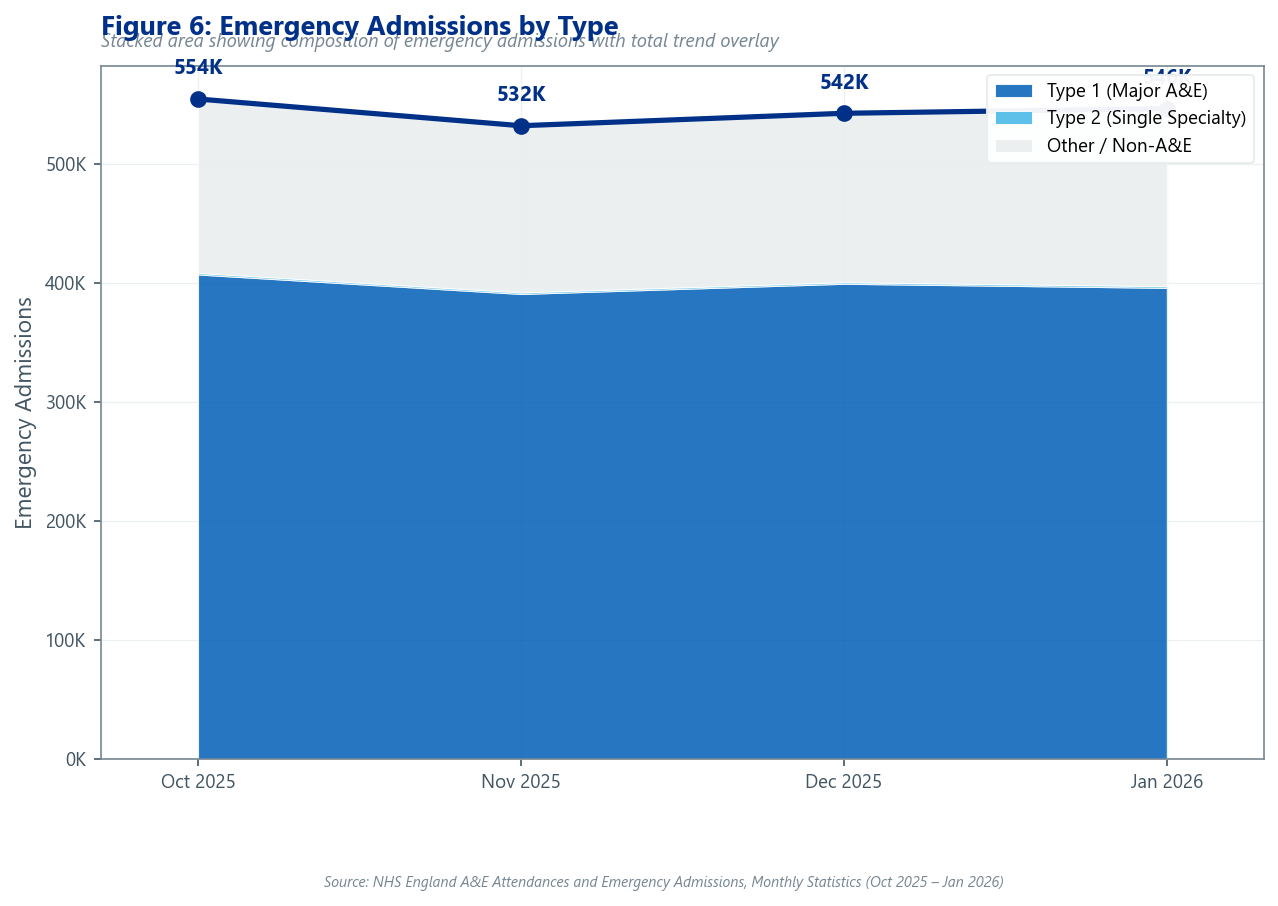

In [39]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(monthly.index))
type1 = monthly["Emergency_Type1"].values
type2 = monthly["Emergency_Type2"].values
other = monthly["Emergency_Other"].values

ax.stackplot(x, type1, type2, other,
             labels=["Type 1 (Major A&E)", "Type 2 (Single Specialty)", "Other / Non-A&E"],
             colors=[NHS_BLUE, NHS_LIGHT_BLUE, NHS_PALE_GREY],
             alpha=0.85, edgecolor="white", linewidth=0.5)

# Total line on top
total = type1 + type2 + other
ax.plot(x, total, color=NHS_DARK_BLUE, linewidth=2.5, marker="o", markersize=7, zorder=5)
for i, val in enumerate(total):
    ax.annotate(f"{val / 1e3:.0f}K", (x[i], val), textcoords="offset points",
                xytext=(0, 12), ha="center", fontsize=10, fontweight="bold", color=NHS_DARK_BLUE)

ax.set_xticks(x)
ax.set_xticklabels(monthly.index)
ax.set_ylabel("Emergency Admissions")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x / 1e3:.0f}K"))
ax.legend(loc="upper right", framealpha=0.95)
ax.set_xlim(-0.3, len(x) - 0.7)

add_figure_title(ax, 6, "Emergency Admissions by Type",
                 "Stacked area showing composition of emergency admissions with total trend overlay")
add_source_footnote(fig)
fig.savefig(os.path.join(OUTPUT_DIR, "06_emergency_admissions_stacked.png"))
plt.show()

### Figure 7: Regional Attendances Heatmap

An annotated heatmap showing A&E attendance volumes across regions and months. Column-normalised colouring ensures that regional variation is visible even when absolute volumes differ significantly. Month-on-month percentage changes are annotated within each cell to highlight demand trends.

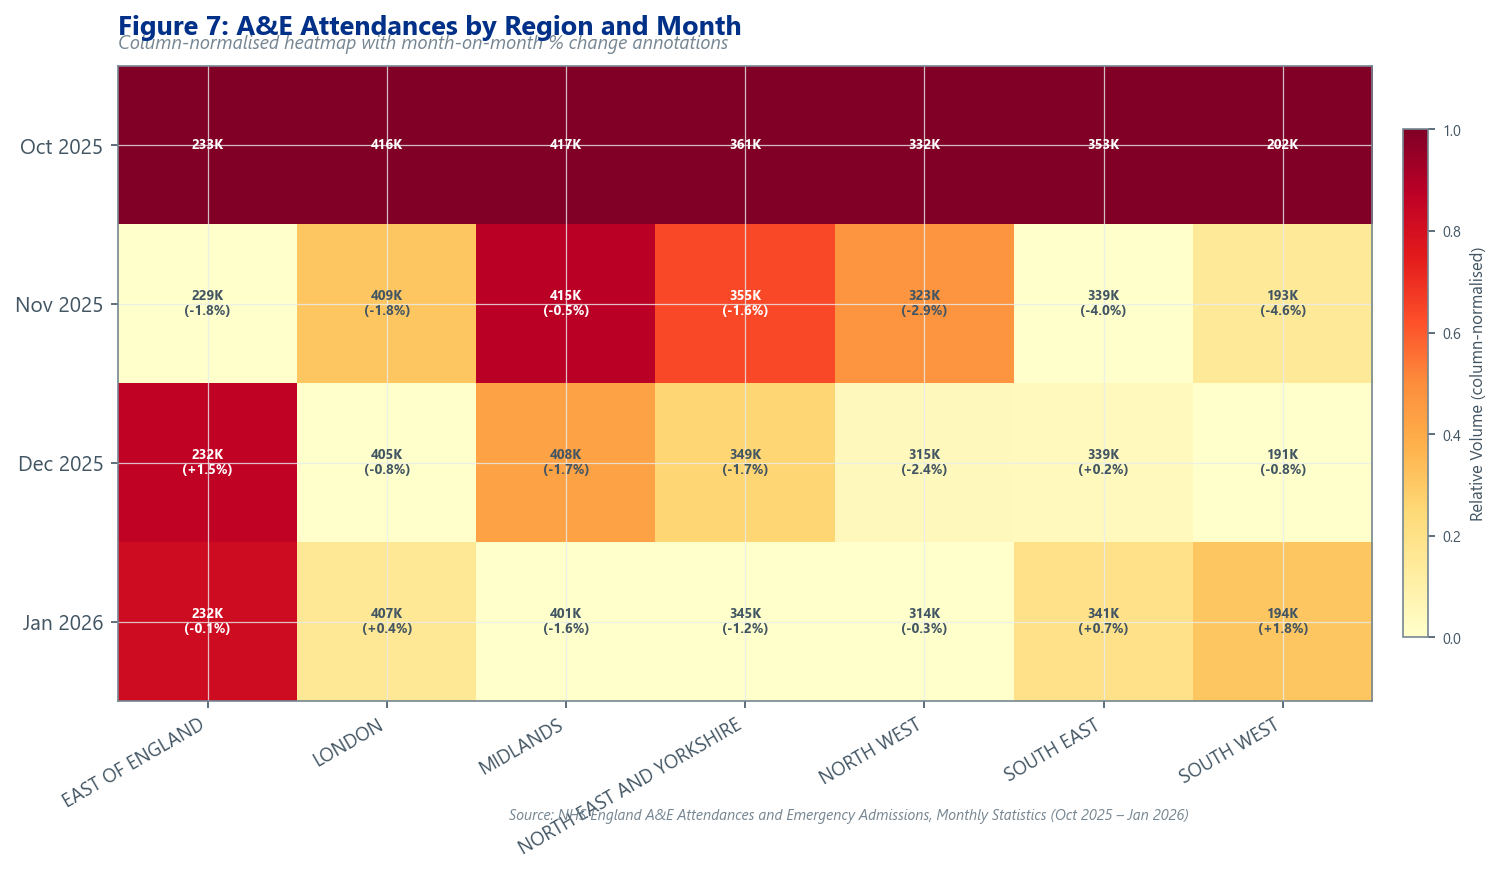

In [42]:
pivot = (
    combined.groupby(["Month", "Region"])["Total Attendances"]
    .sum()
    .unstack(fill_value=0)
    .reindex(MONTH_ORDER)
)
pivot.index = MONTH_LABELS

# Compute % change from previous month
pct_change_hm = pivot.pct_change() * 100

fig, ax = plt.subplots(figsize=(13, 5.5))

# Normalise per column (region) for better colour contrast
norm_data = pivot.values.astype(float)
col_min = norm_data.min(axis=0, keepdims=True)
col_max = norm_data.max(axis=0, keepdims=True)
col_range = np.where(col_max - col_min == 0, 1, col_max - col_min)
norm_vals = (norm_data - col_min) / col_range

im = ax.imshow(norm_vals, cmap="YlOrRd", aspect="auto", vmin=0, vmax=1)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=30, ha="right", fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=10)

# Annotate: value + % change
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        txt = f"{val / 1e3:.0f}K"
        if i > 0 and not np.isnan(pct_change_hm.values[i, j]):
            chg = pct_change_hm.values[i, j]
            arrow = "+" if chg > 0 else ""
            txt += f"\n({arrow}{chg:.1f}%)"
        text_color = "white" if norm_vals[i, j] > 0.55 else NHS_DARK_GREY
        ax.text(j, i, txt, ha="center", va="center", fontsize=6.5, color=text_color, fontweight="bold")

cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("Relative Volume (column-normalised)", fontsize=8)
cbar.ax.tick_params(labelsize=7)

add_figure_title(ax, 7, "A&E Attendances by Region and Month",
                 "Column-normalised heatmap with month-on-month % change annotations")
add_source_footnote(fig)
fig.savefig(os.path.join(OUTPUT_DIR, "07_regional_heatmap.png"))
plt.show()

### Figure 8: 12+ Hour DTA Waits — Waterfall Chart

A waterfall chart tracking the cumulative change in patients waiting 12+ hours from Decision to Admit (DTA). Starting from the October 2025 baseline, each bar shows the monthly increment or decrement, making it easy to identify which months drove the most significant deterioration or improvement.

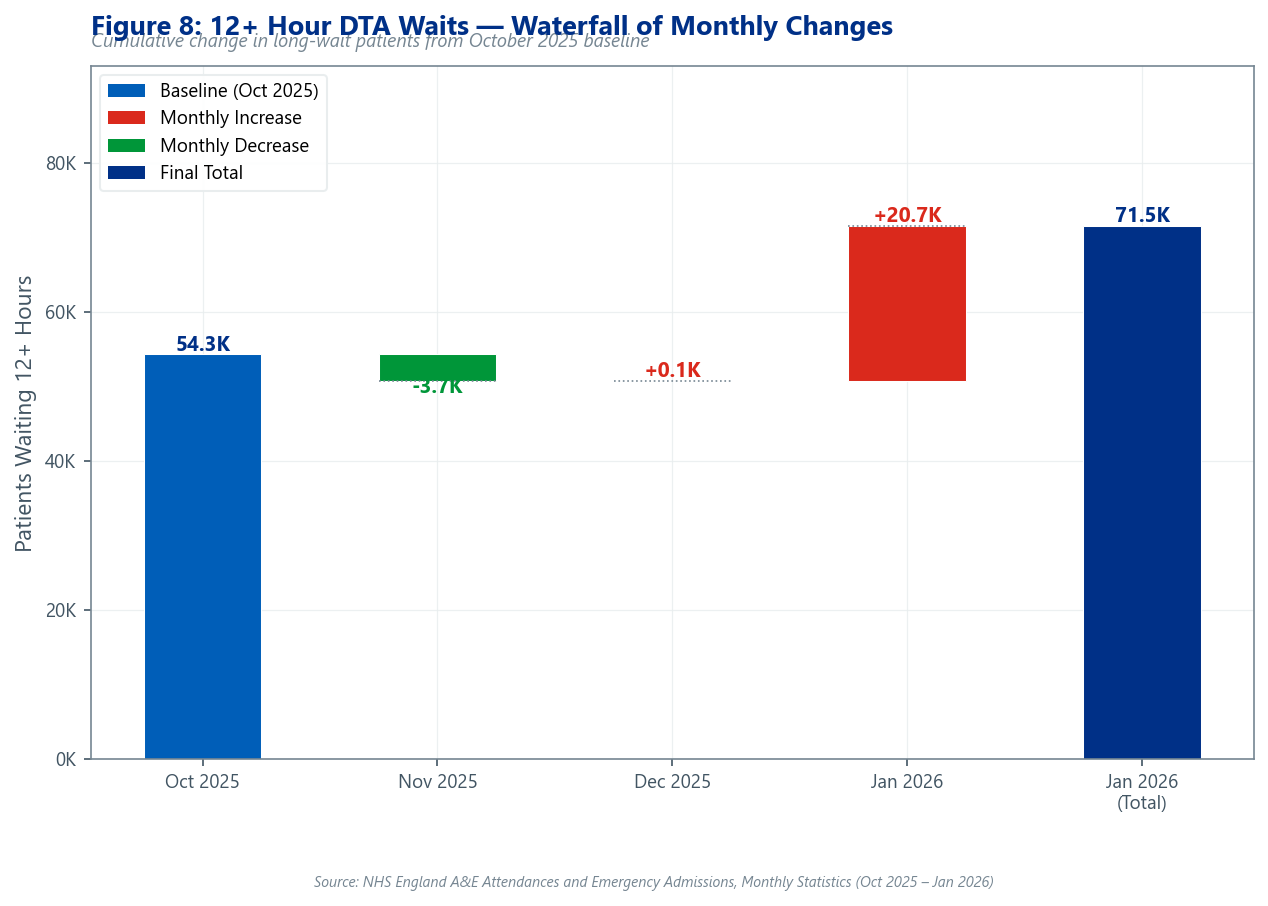

In [44]:
fig, ax = plt.subplots(figsize=(10, 6))

values = monthly["Waited_12plus_hrs"].values
labels = list(monthly.index)
deltas = np.diff(values)

# Plot baseline bar (Oct)
ax.bar(0, values[0], color=NHS_BLUE, width=0.5, edgecolor="white", linewidth=0.5)
ax.text(0, values[0] + 500, f"{values[0] / 1e3:.1f}K", ha="center", fontsize=10,
        fontweight="bold", color=NHS_DARK_BLUE)

# Plot delta bars
running = values[0]
for i, delta in enumerate(deltas):
    color = NHS_RED if delta > 0 else NHS_GREEN
    ax.bar(i + 1, delta, bottom=running, color=color, width=0.5, edgecolor="white", linewidth=0.5)
    # Connector line
    ax.hlines(y=running + delta, xmin=i + 0.75, xmax=i + 1.25, color=NHS_GREY, linewidth=0.8, linestyle=":")
    # Label
    sign = "+" if delta > 0 else ""
    ax.text(i + 1, running + delta + (500 if delta > 0 else -1500),
            f"{sign}{delta / 1e3:.1f}K", ha="center", fontsize=10, fontweight="bold",
            color=color)
    running += delta

# Final total bar
ax.bar(len(labels), values[-1], color=NHS_DARK_BLUE, width=0.5, edgecolor="white", linewidth=0.5)
ax.text(len(labels), values[-1] + 500, f"{values[-1] / 1e3:.1f}K", ha="center", fontsize=10,
        fontweight="bold", color=NHS_DARK_BLUE)

ax.set_xticks(range(len(labels) + 1))
ax.set_xticklabels(labels + [f"{labels[-1]}\n(Total)"], fontsize=9)
ax.set_ylabel("Patients Waiting 12+ Hours")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x / 1e3:.0f}K"))
ax.set_ylim(0, max(values) * 1.3)

# Legend
legend_elements = [
    mpatches.Patch(facecolor=NHS_BLUE, label="Baseline (Oct 2025)"),
    mpatches.Patch(facecolor=NHS_RED, label="Monthly Increase"),
    mpatches.Patch(facecolor=NHS_GREEN, label="Monthly Decrease"),
    mpatches.Patch(facecolor=NHS_DARK_BLUE, label="Final Total"),
]
ax.legend(handles=legend_elements, loc="upper left", framealpha=0.95)

add_figure_title(ax, 8, "12+ Hour DTA Waits — Waterfall of Monthly Changes",
                 "Cumulative change in long-wait patients from October 2025 baseline")
add_source_footnote(fig)
fig.savefig(os.path.join(OUTPUT_DIR, "08_12hr_waits_waterfall.png"))
plt.show()

### Figure 9: Trust-Level Performance Distribution (Violin + Box Plot)

A violin plot overlaid with a box plot to show the full distribution of 4-hour performance across trusts for each month. This reveals not just central tendency (median) but also the spread, skew, and outliers — essential for understanding whether poor national performance is driven by a few extreme outliers or widespread underperformance.

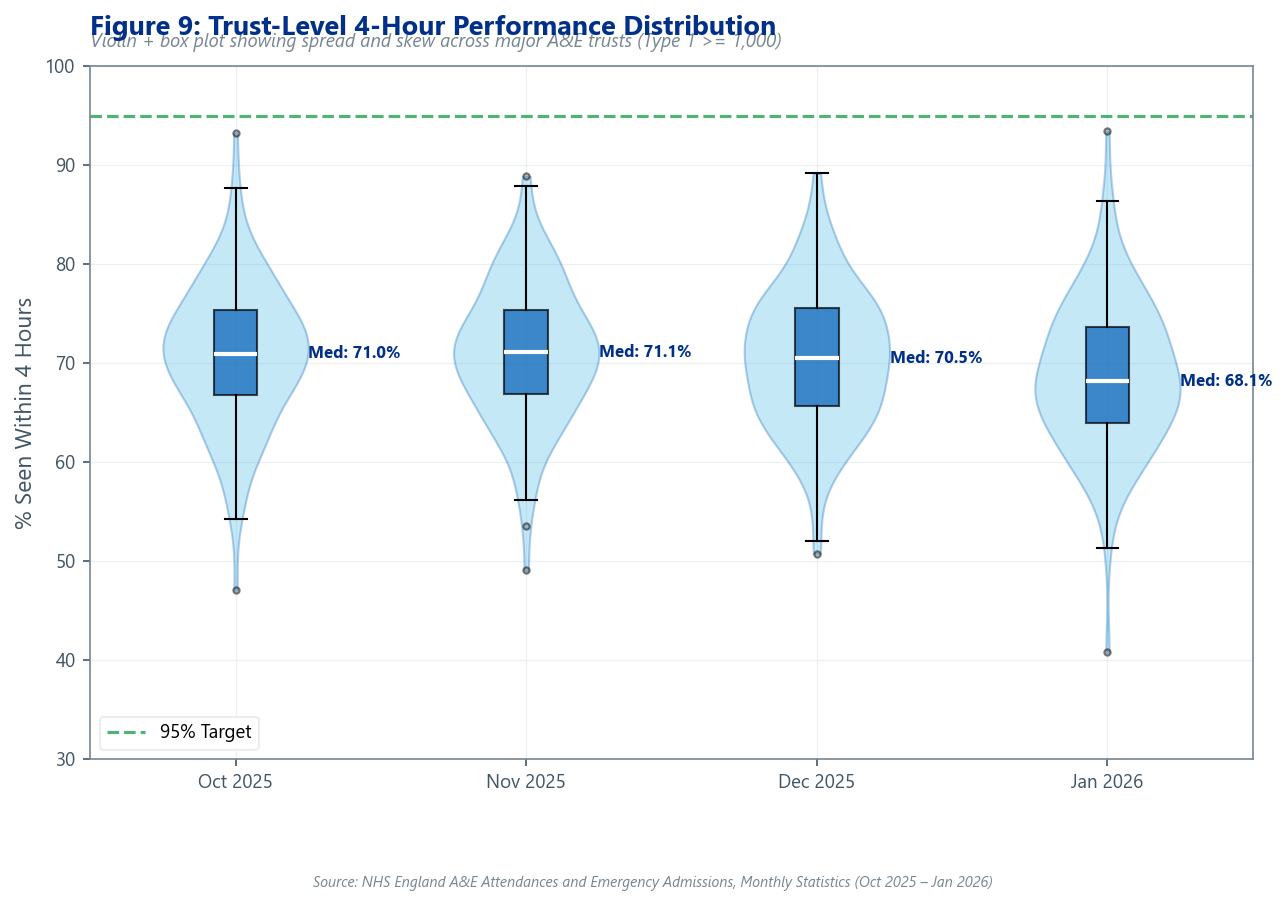

In [47]:
# Filter to trusts with meaningful attendances
valid = combined[(combined["Total Attendances"] > 0) & (combined["A&E attendances Type 1"] >= 1000)].copy()

fig, ax = plt.subplots(figsize=(10, 6))

data_by_month = []
for m in MONTH_ORDER:
    month_data = valid[valid["Month"] == m]["Pct Within 4hrs"].dropna()
    data_by_month.append(month_data.values)

positions = np.arange(1, len(MONTH_LABELS) + 1)

# Violin
vp = ax.violinplot(data_by_month, positions=positions, showmeans=False,
                   showmedians=False, showextrema=False)
for body in vp["bodies"]:
    body.set_facecolor(NHS_LIGHT_BLUE)
    body.set_alpha(0.3)
    body.set_edgecolor(NHS_BLUE)

# Box plot overlaid
bp = ax.boxplot(data_by_month, positions=positions, widths=0.15, patch_artist=True,
                showfliers=True, flierprops=dict(marker="o", markerfacecolor=NHS_GREY,
                                                  markersize=3, alpha=0.5))
for patch in bp["boxes"]:
    patch.set_facecolor(NHS_BLUE)
    patch.set_alpha(0.7)
for median in bp["medians"]:
    median.set_color("white")
    median.set_linewidth(2)

# Median annotations
for i, month_data in enumerate(data_by_month):
    med = np.median(month_data)
    ax.text(positions[i] + 0.25, med, f"Med: {med:.1f}%", fontsize=8,
            color=NHS_DARK_BLUE, fontweight="bold", va="center")

ax.axhline(y=95, color=NHS_GREEN, linewidth=1.5, linestyle="--", alpha=0.7, label="95% Target")
ax.set_xticks(positions)
ax.set_xticklabels(MONTH_LABELS)
ax.set_ylabel("% Seen Within 4 Hours")
ax.set_ylim(30, 100)
ax.legend(loc="lower left")

add_figure_title(ax, 9, "Trust-Level 4-Hour Performance Distribution",
                 "Violin + box plot showing spread and skew across major A&E trusts (Type 1 >= 1,000)")
add_source_footnote(fig)
fig.savefig(os.path.join(OUTPUT_DIR, "09_trust_distribution.png"))
plt.show()

### Figure 10: Volume vs Performance Scatter with OLS Regression

Does higher patient volume predict worse 4-hour performance? This scatter plot tests that hypothesis using Ordinary Least Squares (OLS) regression. Each point represents a trust, colour-coded by region. The R² value and p-value quantify the strength and significance of the relationship.

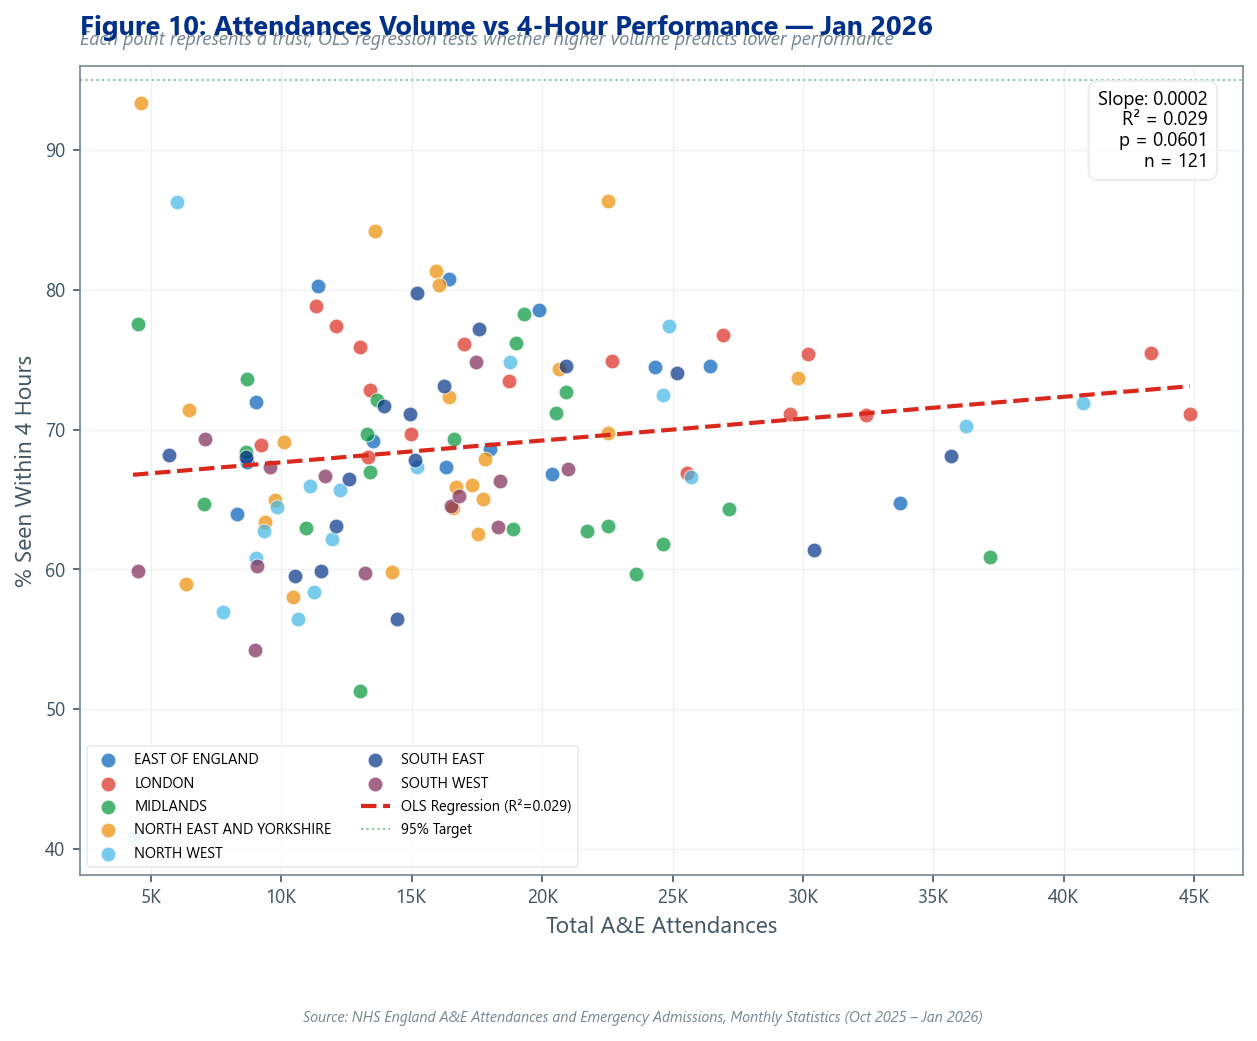

In [50]:
latest = combined[combined["Month"] == MONTH_ORDER[-1]]
trusts = latest[(latest["Total Attendances"] > 0) & (latest["A&E attendances Type 1"] >= 1000)].copy()

x_vals = trusts["Total Attendances"].values
y_vals = trusts["Pct Within 4hrs"].values
valid_mask = ~np.isnan(y_vals)
x_vals, y_vals = x_vals[valid_mask], y_vals[valid_mask]

fig, ax = plt.subplots(figsize=(10, 7))

# Colour by region
regions = trusts[valid_mask.tolist() if isinstance(valid_mask, np.ndarray) else valid_mask]["Region"].values
unique_regions = sorted(set(regions))
region_colors = {r: PALETTE[i % len(PALETTE)] for i, r in enumerate(unique_regions)}

for region in unique_regions:
    mask = regions == region
    ax.scatter(x_vals[mask], y_vals[mask], c=region_colors[region], s=50, alpha=0.7,
               edgecolors="white", linewidth=0.5, label=region, zorder=4)

# Regression line
slope, intercept, r_value, p_value, std_err = stats.linregress(x_vals, y_vals)
x_fit = np.linspace(x_vals.min(), x_vals.max(), 100)
y_fit = slope * x_fit + intercept
ax.plot(x_fit, y_fit, color=NHS_RED, linewidth=2, linestyle="--", zorder=5,
        label=f"OLS Regression (R²={r_value**2:.3f})")

# Reference lines
ax.axhline(y=95, color=NHS_GREEN, linewidth=1, linestyle=":", alpha=0.5, label="95% Target")

# Stats annotation
stats_text = (f"Slope: {slope:.4f}\n"
              f"R² = {r_value**2:.3f}\n"
              f"p = {p_value:.4f}\n"
              f"n = {len(x_vals)}")
ax.text(0.97, 0.97, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment="top", horizontalalignment="right",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor=NHS_PALE_GREY, alpha=0.9))

ax.set_xlabel("Total A&E Attendances")
ax.set_ylabel("% Seen Within 4 Hours")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x / 1e3:.0f}K"))
ax.legend(loc="lower left", fontsize=7, ncol=2, framealpha=0.9)

add_figure_title(ax, 10, f"Attendances Volume vs 4-Hour Performance — {MONTH_LABELS[-1]}",
                 "Each point represents a trust; OLS regression tests whether higher volume predicts lower performance")
add_source_footnote(fig)
fig.savefig(os.path.join(OUTPUT_DIR, "10_volume_vs_performance.png"))
plt.show()

### Figure 11: Regional Performance Trends (Small Multiples)

Small multiples (faceted line charts) allow side-by-side comparison of 4-hour performance trends across all NHS England regions. Each panel shows one region's trajectory from October to January, with start/end annotations and period change in percentage points. This technique avoids the clutter of overlapping lines on a single axis.

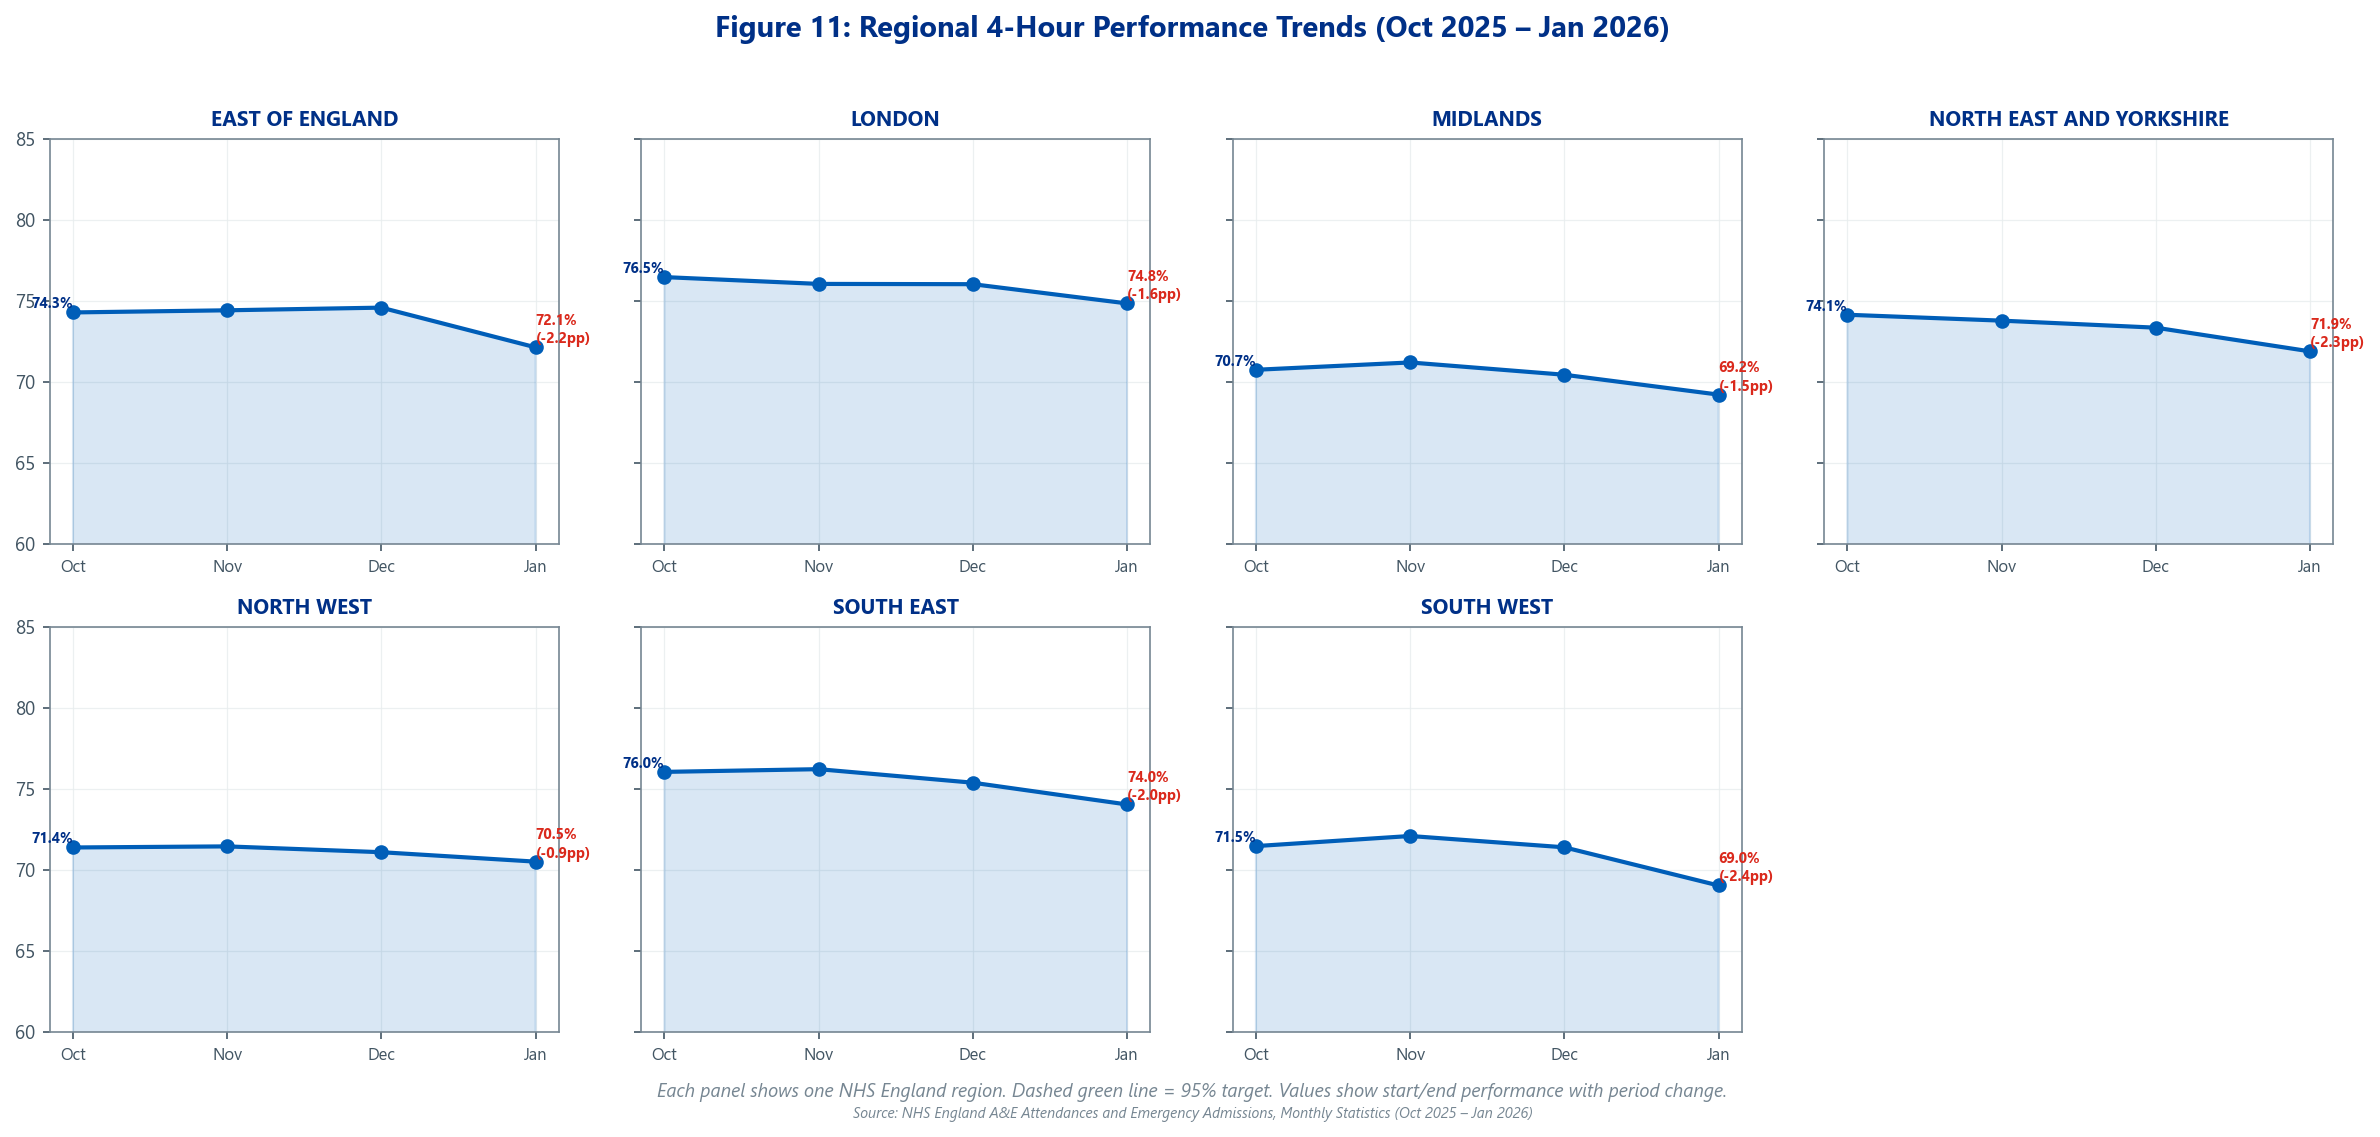

In [52]:
regional_monthly = (
    combined.groupby(["Month", "Region"])
    .agg(Att=("Total Attendances", "sum"), Over4=("Total Over 4hrs", "sum"))
    .reset_index()
)
regional_monthly = regional_monthly[regional_monthly["Att"] > 0]
regional_monthly["Pct"] = (regional_monthly["Att"] - regional_monthly["Over4"]) / regional_monthly["Att"] * 100

regions_list = sorted(regional_monthly["Region"].unique())
n_regions = len(regions_list)
ncols = 4
nrows = (n_regions + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5), sharey=True)
axes_flat = axes.flatten()

for i, region in enumerate(regions_list):
    ax = axes_flat[i]
    data = regional_monthly[regional_monthly["Region"] == region].set_index("Month").reindex(MONTH_ORDER)
    vals = data["Pct"].values

    ax.fill_between(range(len(MONTH_LABELS)), vals, alpha=0.15, color=NHS_BLUE)
    ax.plot(range(len(MONTH_LABELS)), vals, marker="o", color=NHS_BLUE, linewidth=2, markersize=6)
    ax.axhline(y=95, color=NHS_GREEN, linewidth=1, linestyle="--", alpha=0.5)

    # Start and end annotations
    if not np.isnan(vals[0]):
        ax.text(0, vals[0], f"{vals[0]:.1f}%", fontsize=7, fontweight="bold",
                color=NHS_DARK_BLUE, ha="right", va="bottom")
    if not np.isnan(vals[-1]):
        change = vals[-1] - vals[0] if not np.isnan(vals[0]) else 0
        color = NHS_RED if change < 0 else NHS_GREEN
        ax.text(len(MONTH_LABELS) - 1, vals[-1], f"{vals[-1]:.1f}%\n({change:+.1f}pp)",
                fontsize=7, fontweight="bold", color=color, ha="left", va="bottom")

    ax.set_title(region, fontsize=10, fontweight="bold", color=NHS_DARK_BLUE)
    ax.set_xticks(range(len(MONTH_LABELS)))
    ax.set_xticklabels(["Oct", "Nov", "Dec", "Jan"], fontsize=8)
    ax.set_ylim(60, 85)

# Hide unused axes
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle("Figure 11: Regional 4-Hour Performance Trends (Oct 2025 – Jan 2026)",
             fontsize=14, fontweight="bold", color=NHS_DARK_BLUE, y=1.02)
fig.text(0.5, -0.01, "Each panel shows one NHS England region. Dashed green line = 95% target. "
         "Values show start/end performance with period change.",
         ha="center", fontsize=9, color=NHS_GREY, style="italic")
add_source_footnote(fig)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "11_regional_small_multiples.png"))
plt.show()

### Figure 12: Month-on-Month Performance Change Heatmap

A diverging heatmap showing the percentage-point change in 4-hour performance between consecutive months, by region. Green indicates improvement, red indicates deterioration. This makes it easy to identify which regions are improving or worsening and during which periods.

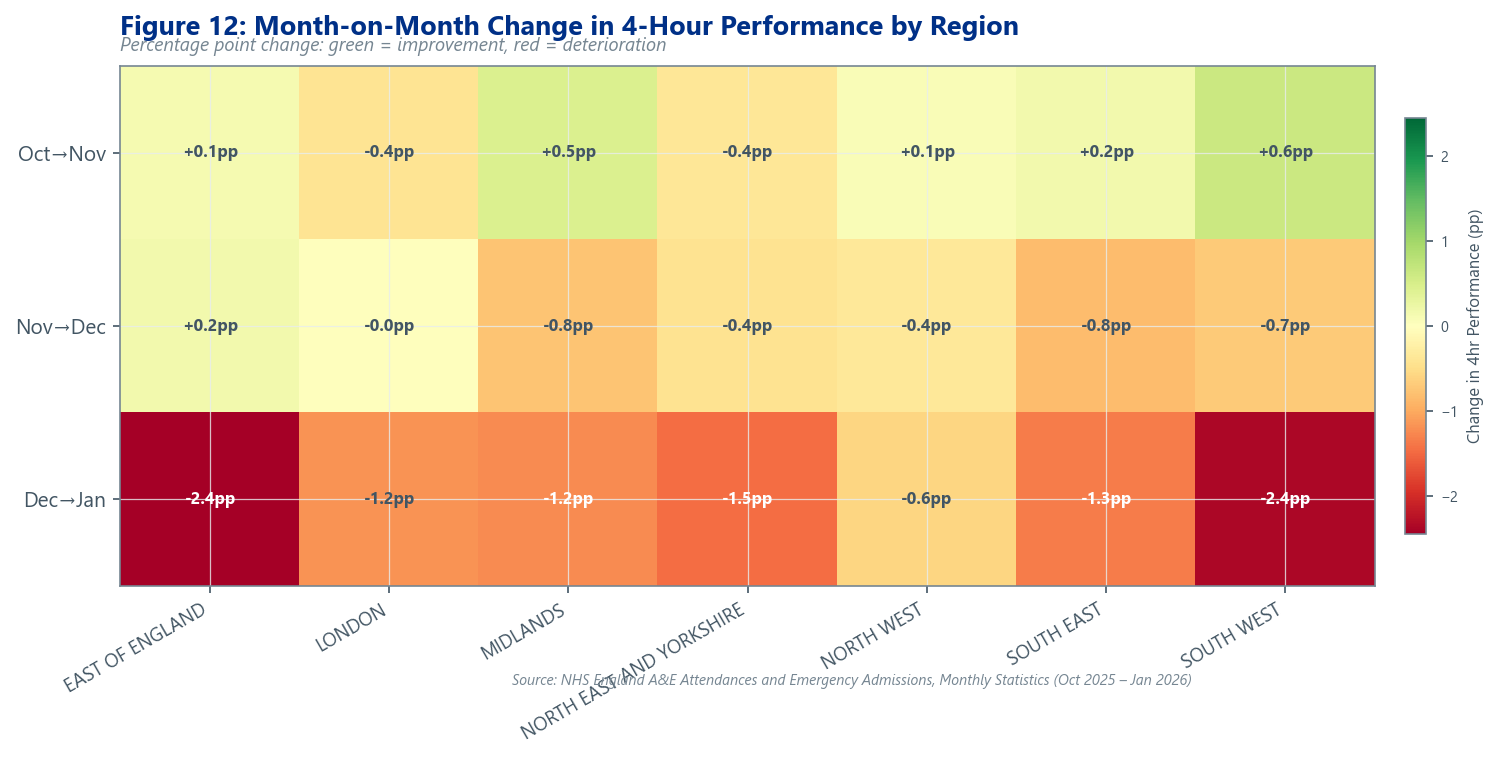

In [54]:
regional_monthly2 = (
    combined.groupby(["Month", "Region"])
    .agg(Att=("Total Attendances", "sum"), Over4=("Total Over 4hrs", "sum"))
    .reset_index()
)
regional_monthly2 = regional_monthly2[regional_monthly2["Att"] > 0]
regional_monthly2["Pct"] = (regional_monthly2["Att"] - regional_monthly2["Over4"]) / regional_monthly2["Att"] * 100

pivot_change = regional_monthly2.pivot(index="Month", columns="Region", values="Pct").reindex(MONTH_ORDER)

# Month-on-month change (percentage points)
change = pivot_change.diff()
change = change.iloc[1:]  # Drop first NaN row
change.index = ["Oct→Nov", "Nov→Dec", "Dec→Jan"]

fig, ax = plt.subplots(figsize=(13, 4.5))

# Diverging colormap
max_abs = np.nanmax(np.abs(change.values))
im = ax.imshow(change.values, cmap="RdYlGn", aspect="auto", vmin=-max_abs, vmax=max_abs)

ax.set_xticks(range(len(change.columns)))
ax.set_xticklabels(change.columns, rotation=30, ha="right", fontsize=9)
ax.set_yticks(range(len(change.index)))
ax.set_yticklabels(change.index, fontsize=10)

# Annotate
for i in range(len(change.index)):
    for j in range(len(change.columns)):
        val = change.values[i, j]
        if np.isnan(val):
            continue
        sign = "+" if val > 0 else ""
        text_color = "white" if abs(val) > max_abs * 0.5 else NHS_DARK_GREY
        ax.text(j, i, f"{sign}{val:.1f}pp", ha="center", va="center",
                fontsize=8, fontweight="bold", color=text_color)

cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("Change in 4hr Performance (pp)", fontsize=8)
cbar.ax.tick_params(labelsize=7)

add_figure_title(ax, 12, "Month-on-Month Change in 4-Hour Performance by Region",
                 "Percentage point change: green = improvement, red = deterioration")
add_source_footnote(fig)
fig.savefig(os.path.join(OUTPUT_DIR, "12_regional_change_heatmap.png"))
plt.show()

---

## 5. Summary Statistics Export

Export key summary tables to CSV for further analysis or inclusion in reports.

In [57]:
# National monthly summary
monthly.to_csv(os.path.join(OUTPUT_DIR, "national_monthly_summary.csv"))

# Regional summary for latest month
latest = combined[combined["Month"] == MONTH_ORDER[-1]]
regional_export = (
    latest.groupby("Region")
    .agg(
        Total_Attendances=("Total Attendances", "sum"),
        Total_Over_4hrs=("Total Over 4hrs", "sum"),
        Emergency_Admissions=("Total Emergency Admissions", "sum"),
        Waited_12plus=("Waited 12+hrs DTA", "sum"),
    )
)
regional_export["Pct_Within_4hrs"] = (
    (regional_export["Total_Attendances"] - regional_export["Total_Over_4hrs"]) / regional_export["Total_Attendances"] * 100
).round(1)
regional_export.to_csv(os.path.join(OUTPUT_DIR, "regional_summary_latest.csv"))

# Trust-level detail for latest month
trust_detail = latest[latest["Total Attendances"] > 0][
    ["Org Code", "Org name", "Region", "Total Attendances", "Total Over 4hrs",
     "Pct Within 4hrs", "Total Emergency Admissions", "Waited 4-12hrs DTA", "Waited 12+hrs DTA"]
].sort_values("Pct Within 4hrs", ascending=True)
trust_detail.to_csv(os.path.join(OUTPUT_DIR, "trust_detail_latest.csv"), index=False)

print("Exported CSVs to output/:")
print("  - national_monthly_summary.csv")
print("  - regional_summary_latest.csv")
print("  - trust_detail_latest.csv")

Exported CSVs to output/:
  - national_monthly_summary.csv
  - regional_summary_latest.csv
  - trust_detail_latest.csv


---

## 6. Key Findings

Programmatic extraction of the headline findings from the analysis. These are derived directly from the data to ensure accuracy and reproducibility.

In [60]:
print("=" * 80)
print("KEY FINDINGS")
print("=" * 80)

oct_pct = monthly.loc["Oct 2025", "Pct_Within_4hrs"]
jan_pct = monthly.loc["Jan 2026", "Pct_Within_4hrs"]
print(f"\n1. 4-HOUR TARGET PERFORMANCE:")
print(f"   - October 2025: {oct_pct:.1f}%  |  January 2026: {jan_pct:.1f}%")
print(f"   - Change: {jan_pct - oct_pct:+.1f} percentage points")
print(f"   - All months significantly below the 95% national target")

oct_12 = monthly.loc["Oct 2025", "Waited_12plus_hrs"]
jan_12 = monthly.loc["Jan 2026", "Waited_12plus_hrs"]
print(f"\n2. 12+ HOUR DTA WAITS:")
print(f"   - October 2025: {oct_12:,.0f}  |  January 2026: {jan_12:,.0f}")
print(f"   - Change: {(jan_12 - oct_12) / oct_12 * 100:+.1f}%")
if jan_12 > oct_12:
    print(f"   - Significant increase during winter months — consistent with seasonal pressure")

latest = combined[combined["Month"] == MONTH_ORDER[-1]]
regional_findings = (
    latest.groupby("Region")
    .agg(Att=("Total Attendances", "sum"), Over4=("Total Over 4hrs", "sum"))
)
regional_findings = regional_findings[regional_findings["Att"] > 0]
regional_findings["Pct"] = ((regional_findings["Att"] - regional_findings["Over4"]) / regional_findings["Att"] * 100)
best_region = regional_findings["Pct"].idxmax()
worst_region = regional_findings["Pct"].idxmin()
print(f"\n3. REGIONAL DISPARITIES (Jan 2026):")
print(f"   - Best performing region:  {best_region} ({regional_findings.loc[best_region, 'Pct']:.1f}%)")
print(f"   - Worst performing region: {worst_region} ({regional_findings.loc[worst_region, 'Pct']:.1f}%)")
print(f"   - Gap: {regional_findings['Pct'].max() - regional_findings['Pct'].min():.1f} percentage points")

busiest = latest.nlargest(5, "Total Attendances")[["Org name", "Total Attendances"]]
print(f"\n4. BUSIEST TRUSTS (Jan 2026):")
for _, row in busiest.iterrows():
    print(f"   - {row['Org name']}: {row['Total Attendances']:,}")

print("\n" + "=" * 80)

KEY FINDINGS

1. 4-HOUR TARGET PERFORMANCE:
   - October 2025: 73.6%  |  January 2026: 71.8%
   - Change: -1.8 percentage points
   - All months significantly below the 95% national target

2. 12+ HOUR DTA WAITS:
   - October 2025: 54,314  |  January 2026: 71,517
   - Change: +31.7%
   - Significant increase during winter months — consistent with seasonal pressure

3. REGIONAL DISPARITIES (Jan 2026):
   - Best performing region:  LONDON (74.8%)
   - Worst performing region: SOUTH WEST (69.0%)
   - Gap: 5.8 percentage points

4. BUSIEST TRUSTS (Jan 2026):
   - BARTS HEALTH NHS TRUST: 44,832
   - ROYAL FREE LONDON NHS FOUNDATION TRUST: 43,338
   - MANCHESTER UNIVERSITY NHS FOUNDATION TRUST: 40,731
   - UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION TRUST: 37,179
   - NORTHERN CARE ALLIANCE NHS FOUNDATION TRUST: 36,255



---

## 7. Conclusion

This analysis of NHS England A&E data from October 2025 to January 2026 reveals several critical insights:

1. **Persistent 4-hour target breach** — National performance remained well below the 95% standard across all months, with winter months showing further deterioration consistent with seasonal demand patterns.

2. **Growing long-wait problem** — The number of patients waiting 12+ hours from Decision to Admit increased significantly from October to January, indicating worsening flow and capacity constraints during the winter period.

3. **Significant regional variation** — Performance varies substantially across NHS England regions, with some regions consistently outperforming others. This disparity suggests that system-level factors (bed capacity, staffing models, patient flow processes) play a significant role beyond raw demand.

4. **Volume-performance relationship** — The scatter analysis with OLS regression explores whether higher attendance volumes correlate with worse performance, providing evidence for or against the hypothesis that demand is the primary driver of 4-hour breaches.

5. **Trust-level heterogeneity** — The violin plot distributions show substantial spread across trusts within each month, indicating that even within the same period, some trusts manage significantly better outcomes than others — pointing to operational and organisational factors as key differentiators.

### Limitations
- Data covers only 4 months — longer time series would strengthen trend analysis
- No adjustment for case-mix, deprivation, or acuity differences between trusts
- Type 2 and "Other" departments have different clinical profiles that may not be directly comparable with Type 1 Major A&E departments

### Further Work
- Integrate historical data (2019–2024) for pre/post-pandemic trend comparison
- Link with workforce data (staffing levels, vacancy rates) to test capacity hypotheses
- Apply time-series forecasting methods to predict future performance trajectories